## Running the Lorenz 1996 Model


### Introduction to the Lorenz, 1996 Model
The Lorenz, 1996 system is an idealised model of mid-latitude atmospheric dynamics around a latitude circle. It is commonly used as a testbed for machine learning parameterisations (e.g., Gagne II et al., 2020; Parthipan et al., 2023; Rasp, 2020), including stochastic parameterisations (e.g., Arnold et al., 2013; Wilks, 2005). Here, we will use it as a testbed model to separate aleatoric and epistemic uncertainty in parameterisations. 

We start by introducing the one-layer model, which is defined on a periodic grid of size $K$. The variables, $X_{k}$ where $k = 1, ..., K$ and $X_{K}=X_{0}$, evolve following:
$$
\frac{dX_{k}}{dt} = -X_{k-1} (X_{k-2}-X_{k+1} ) - X_k + F 
$$
where $F$ is an external forcing (usually fixed at a constant, here we use $F=20$). This can be solved with a numerical method of choice - we use RK2. 


This can be extended to the two-layer model where we have two coupled variables: 
* $X_{k}$: large-scale variables defined on the periodic grid $k = 1, ..., K$
* $Y_{j}$: small-scale variables defined on a finer period grid, $j=1,...,J$ between each $X_k$.

Here, we use $K=8$ and $J=32$ meaning we have 32 small-scale variables for each large-scale variable (256 in total). $X$ and $Y$ evolve following:

$$
\frac{dX_{k}}{dt} = -X_{k-1} (X_{k-2}-X_{k+1} ) -X_k + F + \frac{-hc}{b} \Sigma_{j=J(k-1)+1}^{kJ} Y_j 
$$

$$
\frac{dY_{j}}{dt} = -cbY_{j+1} (Y_{j+2}-Y_{j-1} )-cY_j+\frac{ hc}{b}X_{int[j-1/J]+1} 
$$

where the int notation refers to the integer value of the term inside the brackets (i.e., the closest $X$ variable) and $b=10$, $c=10$, and $h=1$ are user-defined parameters of the system that describe the spatial scale ratio, the temporal scale ratio and a coupling constant, respectively. 

This two layer model can be thought of as a 'high resolution' version of the model, capturing the fine scale processes through the coupling to $Y_{j}$, while the one layer represents a 'low resolution' version. We can use this setup to learn a machine learning component (a parameterisation) that helps our low res, 1-layer version behave more like the 2-layer version. 
To do this, we will learn a parameterisation, U, which allows us to run the low-resolution model:
$$
\frac{dX_{k}}{dt} = -X_{k-1} (X_{k-2}-X_{k+1} ) -X_k + F + U(X_k)
$$
where U(X_k) approximately captures all the subgrid-processes (the $Y$ terms), learned with a neural network from large-scale $X_k$ only.

First, we import required packages

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Imports from this package: the L96 Two Layer Model and function to estimate subgrid component
from L96.L96_model import L96TwoLayer, subgrid_component

Define the parameters and constants of our model. We will run the model for time `T=100` with a timestep `dt=0.001`.

In [2]:
# Random seed
seed = 123
np.random.seed(seed)

# Define dimensions of system (fixed)
K = 8   
J = 32  

# Define the "true" parameters
h = 1
F = 20
c = 10
b = 10

# Define time-stepping, random seed
dt = 0.001
T = 100        # Approx ~1.5 years
spinup_T = 1000

Prepare and run the model. The class `L96TwoLayer` initialises the two layer model with the chosen settings. Then, we use `.iterate` to step forwards in time for `T` timesteps using the RK4 scheme. We will start from initial conditions, so we need to spin-up the model to reach the attractor.

In [ ]:
# Save the data we generate to file
data_path = f'./outputs/'
if not os.path.exists(data_path):
    os.makedirs(data_path)

# Random initial conditions
X0 = np.random.rand(K)
Y0 = np.random.rand(K*J)

# Set up model
lorenz_model = L96TwoLayer(X_0=X0, Y_0=Y0, F=F, c=c, b=b, h=h, dt=dt)
print(f"Lorenz 1996 model initialized. Spin-up {spinup_T}...")
X, Y, U_true, time = lorenz_model.iterate(spinup_T)

print(f"Spin-up done. Running for time={T}...")
X, Y, U_true, time = lorenz_model.iterate(T)
print("Lorenz 1996 model run finished. Saving data...")

# Save last X and Y for initialization of test simulations
np.save(f'{data_path}/X_init.npy', X[-1])
np.save(f'{data_path}/Y_init.npy', Y[-1])


Lorenz 1996 model initialized. Spin-up 1000...


In [8]:
X.shape

torch.Size([100000, 8])

Text(0, 0.5, 'X_0')

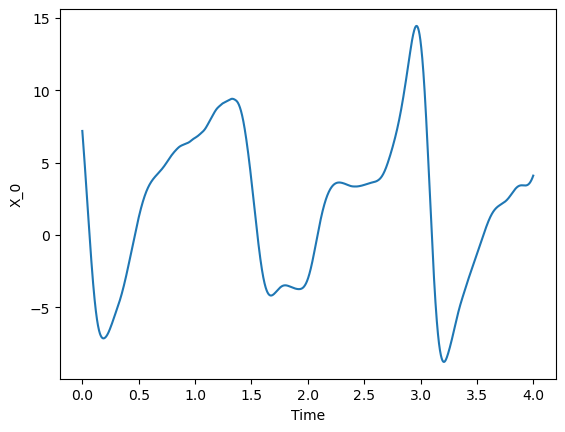

In [13]:
# Plot timeseries for the X variables for the first 1 time unit
plt.plot(time[:4000], X[:4000, 0])
plt.xlabel("Time")
plt.ylabel("X_0")

### Saving the data

Next, we will store the data for ML training in the next notebook, which will then be embedded into the one-layer model. One of the benefits of this is that we can run the one layer model at a coarser timestep (due to the CFL condition), making it more computationally affordable. We will use a forecast timestep of `dt_f=0.005`, 5x larger than our original timestep. we will use the X-data to approximate the subgrid-term U. This is also analagous to what we would do when learning the subgrid term from high resolution model data (ie coarsen the data over time and space, rather than just space). This creates our training data.

In [4]:

## Save data at dt_f = 0.005 for training
subsample_factor = 5
dt_f = dt * subsample_factor
print(f"Subsampling data by factor {subsample_factor} to dt_f = {dt_f}")
X_all = X
X = X[::subsample_factor]
time_subsample = time[::subsample_factor]
U_est = subgrid_component(X[1:], X[:-1], dt_f, F)
np.save(f'{data_path}/U_train_dtf.npy', U_est)

X = X[1:]
np.save(f'{data_path}/X_train_dtf.npy', X)


Subsampling data by factor 5 to dt_f = 0.005


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


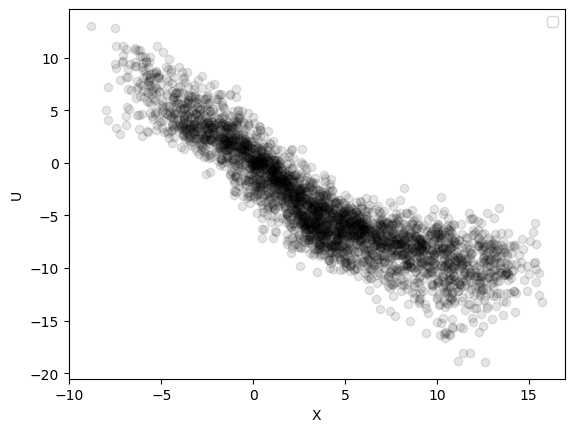

In [13]:
plt.clf()
plt.scatter(X[::50], U_est[::50], alpha=0.1, color="k")
plt.xlabel("X")
plt.ylabel("U")
plt.legend()

### References
* Arnold, H. M., Moroz, I. M., & Palmer, T. N. (2013). Stochastic parametrizations and model uncertainty in the Lorenz ’96 system. Philosophical Transactions of the Royal Society A: Mathematical, Physical and Engineering Sciences, 371(1991), 20110479. https://doi.org/10.1098/rsta.2011.0479
* Gagne II, D. J., Christensen, H. M., Subramanian, A. C., & Monahan, A. H. (2020). Machine Learning for Stochastic Parameterization: Generative Adversarial Networks in the Lorenz ’96 Model. Journal of Advances in Modeling Earth Systems, 12(3), e2019MS001896. https://doi.org/10.1029/2019MS001896
* Lorenz, E. N. (2006). Predictability – a problem partly solved. In R. Hagedorn & T. Palmer (Eds.), Predictability of Weather and Climate (pp. 40–58). Cambridge University Press. https://doi.org/10.1017/CBO9780511617652.004
* Parthipan, R., Christensen, H. M., Hosking, J. S., & Wischik, D. J. (2023). Using probabilistic machine learning to better model temporal patterns in parameterizations: A case study with the Lorenz 96 model. Geoscientific Model Development, 16(15), 4501–4519. https://doi.org/10.5194/gmd-16-4501-2023
* Rasp, S. (2020). Coupled online learning as a way to tackle instabilities and biases in neural network parameterizations: General algorithms and Lorenz 96 case study (v1.0). Geoscientific Model Development, 13(5), 2185–2196. https://doi.org/10.5194/gmd-13-2185-2020
* Wilks, D. S. (2005). Effects of stochastic parametrizations in the Lorenz ’96 system. Quarterly Journal of the Royal Meteorological Society, 131(606), 389–407. https://doi.org/10.1256/qj.04.03
